In [1]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

Definisco la mia condizione iniziale e al contorno del sistema

In [2]:
def init_CC(n, rho, R):
    i = 0
    a = 1./(rho)**(1/3)
    for k in range(n):
        for l in range(n):
            for m in range(n):
                R[i][0] = k*a
                R[i][1] = l*a
                R[i][2] = m*a
                i+=1

In [3]:
def init_BCC(n, rho, R):
    i = 0
    a = 2./(rho)**(1/3)
    for k in range(n):
        for l in range(n):
            for m in range(n):
                R[i][0] = k*a
                R[i][1] = l*a
                R[i][2] = m*a
                i+=1
                R[i][0] = k*a + 1./2
                R[i][1] = l*a + 1./2
                R[i][2] = m*a + 1./2
                i+=1

Definisco le funzioni per calcolare le distanze

In [25]:
def dist(R, p, q, L):
    return sqrt((R[p][0]-R[q][0]-L*rint((R[p][0] - R[q][0])/L))*(R[p][0]-R[q][0]-L*rint((R[p][0] - R[q][0])/L))+(R[p][1]-R[q][1]-L*rint((R[p][1] - R[q][1])/L))*(R[p][1]-R[q][1]-L*rint((R[p][1] - R[q][1])/L))+(R[p][2]-R[q][2]-L*rint((R[p][2] - R[q][2])/L))*(R[p][2]-R[q][2]-L*rint((R[p][2] - R[q][2])/L)))

In [26]:
def dist2(R, Rpq, p, q, L):
    Rpq[0] = R[p][0] - R[q][0]-L*rint((R[p][0] - R[q][0])/L)
    Rpq[1] = R[p][1] - R[q][1]-L*rint((R[p][1] - R[q][1])/L)
    Rpq[2] = R[p][2] - R[q][2]-L*rint((R[p][2] - R[q][2])/L)

Definisco il potenziale di Lennard-Jones

In [17]:
def V(r, L, sigma, epsilon):
    r6 = (sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)*(sigma/r)
    L6 = (2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)*(2*sigma/L)
    if r<=L/2:
        return 4*epsilon*r6*(r6 - 1) - 4*epsilon*L6*(L6 - 1)
    else:
        return 0

Definisco le funzioni u facenti parte della funzione d'onda

In [20]:
def u(r_ij, alpha1):
    return (alpha1/r_ij)*(alpha1/r_ij)*(alpha1/r_ij)*(alpha1/r_ij)*(alpha1/r_ij)

In [ ]:
def u2(r_ij, alpha1, L):
    if r_ij<=L/2:
        return u(r_ij, alpha1) + u(L-r_ij, alpha1) - 2*u(L/2, alpha1)
    else:
        return 0

In [ ]:
def u_prime(r_ij, alpha1, L):
    return -5*u_2(r_ij, alpha1, L)/r_ij

In [ ]:
def u_second(r_ij, alpha1, L):
    return 30*u_2(r_ij, alpha1, L)/(r_ij*r_ij)

Definisco la funzione d'onda e il suo modulo quadro

In [27]:
def psi(R, alpha1, L):
    u_f = 0
    for i in range(N-1):
        for j in range(N):
            r_ij = dist(R, i, j, L)
            u_f += u2(r_ij, alpha1, L)
    
    return np.exp((-1./2)*u_f)

In [28]:
def wf(R, alpha1, L):
    psii = psi(R, alpha1, L)
    return psii*psii

Definisco la funzione che attua il metodo di Montecarlo

In [29]:
def montecarlo(R, D, L, alpha, sigma, epsilon):
    accept = reject = 0

Dichiaro e inizializzo le variabili del problema

In [19]:
N = 64
n = 4
rho = 0.0218
L = (N/rho)**(1/3)
D = 0.27
eps = 10.22
sigma = 2.556
alpha = 2.5
R = np.zeros((N,3))

Creo il mio sistema iniziale e faccio un plot delle particelle in questa configurazione

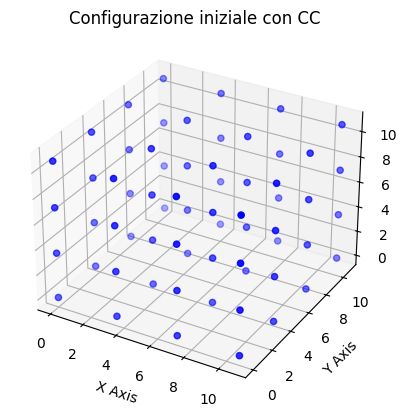

In [31]:
init_CC(n, rho, R)

x = R[:, 0]
y = R[:, 1]
z = R[:, 2]

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.scatter(x, y, z, c='blue', s=20)
plt.title("Configurazione iniziale con CC")
plt.show()